## Basic plotting of variable resolution grid resolution `uxarray` and `matplotlib` (Use environment `NPL 2025b`)

This notebook shows how to easily plot a variable resolution MPAS mesh. Make sure you use the environment `NPL 2025b`

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np
import uxarray as ux
from scipy.ndimage import gaussian_filter
import math

In [2]:
# Set the location of your *grid.nc file
grid_file = "../240-48km_variable/SouthAmerica.grid.nc"
ds = ux.open_dataset(grid_file,grid_file,decode_times=False)

In [3]:
# Set minDX and maxDX of your mesh for nice plotting
minDX, maxDX = 48, 240

# If you don't want a global map, set your extent here. Also, change the extent in the plotting cell
#   to ax.set_extent instead of ax.set_global.
minLon, maxLon = -111, -34
minLat, maxLat = -5, 76

In [4]:
# Reading in the areaCell variable and doing some fun rad to deg math and set up log colorbar.
# Math comes from Michael Duda's mesh_resolution.py script
uxda_area = ds["areaCell"].values
uxda_den = ds["meshDensity"].values

# Scale area if on a unit sphere
if np.sum(uxda_area) < 4.0 * np.pi * 2.0:
    uxda_area = uxda_area * (6371229.0**2)

# Calculate nominal cell spacing field from mesh density
minSpacingKm = np.sqrt(np.min(uxda_area) * 2.0 / np.sqrt(3.0)) * 0.001
fld_km = minSpacingKm / np.power(uxda_den,0.25)

# Assign log10 values back into UXarray dataset
ds["log_dx"] = (ds["areaCell"].dims[0],np.log10(np.clip(fld_km,minDX,maxDX)))

log_space_ticks = np.linspace(np.log10(minDX),np.log10(maxDX), 13)
discrete_cmap = plt.colormaps["GnBu_r"].resampled(12)
norm = mcolors.BoundaryNorm(boundaries=log_space_ticks,ncolors=discrete_cmap.N)

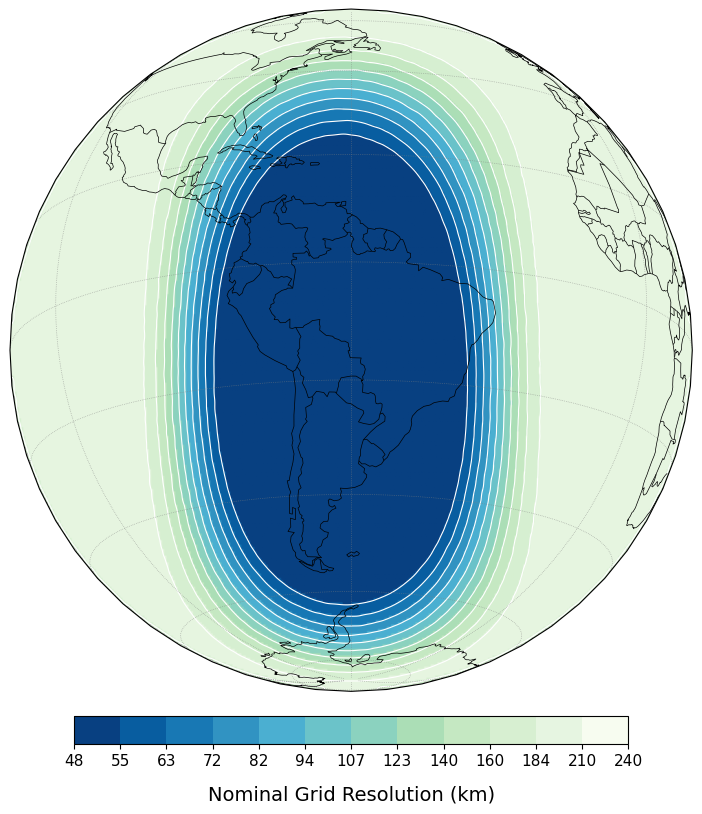

In [5]:
projection = ccrs.Orthographic(central_longitude=-60,central_latitude=-15)
fig, ax = plt.subplots(figsize=(8,8),dpi=50,subplot_kw={"projection": projection},facecolor="w",layout="constrained")
#ax.set_extent([minLon,maxLon,minLat,maxLat],crs=ccrs.PlateCarree())
ax.set_global()

raster = ds["log_dx"].to_raster(ax=ax)
raster_smooth = gaussian_filter(np.nan_to_num(raster,nan=np.nanmean(raster)),sigma=1.5)+(raster*0)
extent = ax.get_xlim() + ax.get_ylim()

# Draw filled contours
im = ax.imshow(raster_smooth,origin="lower",extent=extent,transform=projection,cmap=discrete_cmap,norm=norm,zorder=1)

# Draw white contours on top of filled contour borders so they pop
ny, nx = raster.shape
x, y = np.linspace(extent[0],extent[1],nx),np.linspace(extent[2],extent[3],ny)
ax.contour(x,y,raster_smooth,levels=log_space_ticks[1:-1],
           colors="white",linewidths=0.8,transform=projection,zorder=2)

# Add borders and gridlines
ax.add_feature(cfeature.COASTLINE.with_scale("110m"),linewidth=0.5,edgecolor="black",zorder=3)
ax.add_feature(cfeature.BORDERS.with_scale("110m"),linewidth=0.5,edgecolor="black",zorder=3)
ax.gridlines(color="gray",linestyle=":",linewidth=0.5,alpha=0.7,zorder=4)

cbar = fig.colorbar(im,ax=ax,orientation="horizontal",pad=0.03,shrink=0.7,ticks=log_space_ticks)
cbar.ax.set_xticklabels([f"{10**t:.0f}" for t in log_space_ticks],fontsize=11)
cbar.set_label("Nominal Grid Resolution (km)",fontsize=14,labelpad=12)

fig.set_dpi(100)
#plt.savefig("domain_varres.jpg",bbox_inches="tight",dpi=300)
plt.show()